# 01 - ContraDoc EDA: Evidence / Reference Findability + Sample Composition

Two filter checks run before any LLM extraction:

1. **Findability.** For every YES doc, the `evidence` (inserted contradicting sentence) and each `ref_sentences` entry should appear verbatim or near-verbatim in `text`. Notebook 02's fuzzy resolver depends on this to recover the gold `sentence_id`s. Flag any doc whose evidence or refs cannot be located even by sentence-level `SequenceMatcher` >= 0.85.
2. **Evidence-ref self-reference.** Some docs ship with `evidence` text that is **byte-identical to one of the refs** after normalization. No real contradiction signal. Strict `sim == 1.0` cut: anything below often differs by just a single negation/antonym/number, which is a valid contradiction.

Plus five sample-composition checks for stratification and confound-checking:

3. Multi-label `contra_type` distribution + co-occurrence.
4. Document length (sentences and tokens).
5. Same-base-doc clusters (multiple contradiction insertions over the same source story).
6. Number of refs per YES doc.
7. Evidence/reference sentence position and inter-distance.

**Input:** `data/processed/ContraDoc/ContraDoc.csv`  
**Outputs:**
- `data/processed/ContraDoc/findability.json` - usable / excluded YES `doc_id`s + base-doc clusters + criteria
- `plots/01_EDA_ContraDoc/*.png` - high-DPI plots

In [1]:
import json
import re
from collections import Counter, defaultdict
from difflib import SequenceMatcher
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

INPUT_PATH = Path("data/processed/ContraDoc/ContraDoc.csv")
OUTPUT_PATH = Path("data/processed/ContraDoc/findability.json")
PLOT_DIR = Path("plots/01_EDA_ContraDoc")
PLOT_DIR.mkdir(parents=True, exist_ok=True)
FUZZY_THRESHOLD = 0.85
SELF_REF_THRESHOLD = 1.0  # strict: only flag pairs byte-identical after _normalize

## Load and overview

In [2]:
df = pd.read_csv(INPUT_PATH)
print(f"Total docs: {len(df)}")
print(f"  YES: {(df['contradiction'] == 'YES').sum()}")
print(f"  NO:  {(df['contradiction'] == 'NO').sum()}")
print()
print("By doc_type:")
print(df.groupby(["doc_type", "contradiction"]).size().unstack(fill_value=0))
print()
yes = df[df["contradiction"] == "YES"].copy()
yes_with_ref = yes[yes["ref_sentences"] != "none"]
print(f"YES with ref_sentences != 'none': {len(yes_with_ref)} / {len(yes)}")
print(f"YES with ref_sentences == 'none': {len(yes) - len(yes_with_ref)}  (no recoverable gold pair)")

Total docs: 891
  YES: 449
  NO:  442

By doc_type:
contradiction   NO  YES
doc_type               
news           154  158
story          143  141
wiki           145  150

YES with ref_sentences != 'none': 377 / 449
YES with ref_sentences == 'none': 72  (no recoverable gold pair)


## Fuzzy-match helpers

Same normalization and `SequenceMatcher` ratio that notebook 02 uses to recover gold `sentence_id`s. Coarse-split `text` on sentence terminators (`.`, `!`, `?`) followed by whitespace.

In [3]:
_SENT_SPLIT_RE = re.compile(r"(?<=[.!?])\s+")


def _normalize(text: str) -> str:
    return re.sub(r"\s+", " ", text).strip().lower().rstrip(".!?\"'")


def split_sentences(text: str) -> list[str]:
    return [s for s in _SENT_SPLIT_RE.split(text) if s.strip()]


def find_target(target: str, doc_text: str, threshold: float = FUZZY_THRESHOLD) -> dict:
    """Try to locate `target` within `doc_text`. Returns dict with found/mode/score/matched/idx.
    `idx` is the 0-indexed position in split_sentences(doc_text), or -1 for unmatched."""
    t_norm = _normalize(target)
    d_norm = _normalize(doc_text)
    sentences = split_sentences(doc_text)
    best_idx, best_score, best_sent = -1, 0.0, ""
    for i, s in enumerate(sentences):
        s_n = _normalize(s)
        if t_norm and (s_n == t_norm or t_norm in s_n):
            return {"found": True, "mode": "exact_substring", "score": 1.0, "matched": s, "idx": i}
        score = SequenceMatcher(None, s_n, t_norm).ratio()
        if score > best_score:
            best_idx, best_score, best_sent = i, score, s
    if t_norm and t_norm in d_norm:
        return {"found": True, "mode": "exact_substring", "score": 1.0, "matched": target, "idx": best_idx}
    if best_score >= threshold:
        return {"found": True, "mode": "fuzzy_sentence", "score": best_score, "matched": best_sent, "idx": best_idx}
    return {"found": False, "mode": "none", "score": best_score, "matched": best_sent, "idx": -1}


def evidence_ref_similarity(evidence: str, refs: list[str]) -> tuple[float, str]:
    """Max SequenceMatcher ratio between (normalized) evidence and any ref."""
    ev_n = _normalize(evidence)
    best_score, best_ref = 0.0, ""
    for r in refs:
        score = SequenceMatcher(None, ev_n, _normalize(r)).ratio()
        if score > best_score:
            best_score, best_ref = score, r
    return best_score, best_ref

## Run findability + self-reference check

Captures evidence/ref sentence index too (for the position check below).

In [4]:
results: list[dict] = []
for row in yes_with_ref.itertuples(index=False):
    refs = [r for r in str(row.ref_sentences).split("|") if r.strip()]
    ev = find_target(row.evidence, row.text)
    ref_results = [find_target(r, row.text) for r in refs]
    self_sim, _closest = evidence_ref_similarity(row.evidence, refs)
    n_sentences = len(split_sentences(row.text))

    fully_findable = ev["found"] and all(r["found"] for r in ref_results)
    self_ref = self_sim >= SELF_REF_THRESHOLD
    results.append(
        {
            "doc_id": row.id,
            "doc_type": row.doc_type,
            "contra_type": row.contra_type,
            "n_refs": len(refs),
            "n_sentences": n_sentences,
            "evidence_found": ev["found"],
            "evidence_mode": ev["mode"],
            "evidence_score": ev["score"],
            "evidence_idx": ev["idx"],
            "refs_all_found": all(r["found"] for r in ref_results) if ref_results else None,
            "refs_n_found": sum(1 for r in ref_results if r["found"]),
            "refs_min_score": min((r["score"] for r in ref_results), default=0.0),
            "refs_idxs": [r["idx"] for r in ref_results],
            "fully_findable": fully_findable,
            "self_ref_sim": self_sim,
            "self_ref": self_ref,
            "usable": fully_findable and not self_ref,
        }
    )
res_df = pd.DataFrame(results)
print(f"Checked {len(res_df)} YES docs (those with ref_sentences != 'none').")
res_df.head()

Checked 377 YES docs (those with ref_sentences != 'none').


,doc_id,doc_type,contra_type,n_refs,n_sentences,evidence_found,evidence_mode,evidence_score,evidence_idx,refs_all_found,refs_n_found,refs_min_score,refs_idxs,fully_findable,self_ref_sim,self_ref,usable
0,3488771849_5,story,Content,1,14,True,exact_substring,1.0,8,True,1,1.0,[13],True,0.122581,False,True
1,3488771853_2,story,Content,1,22,True,exact_substring,1.0,10,True,1,1.0,[15],True,0.225806,False,True
2,3488771854_6,story,Content|Emotion/Mood/Feeling,1,25,True,exact_substring,1.0,7,True,1,1.0,[9],True,0.722222,False,True
3,3488771854_8,story,Relation,1,22,True,exact_substring,1.0,10,True,1,1.0,[0],True,0.198758,False,True
4,3488771855_1,story,Content|Emotion/Mood/Feeling,1,35,True,exact_substring,1.0,27,True,1,1.0,[1],True,0.694561,False,True


## Aggregate findability

In [5]:
def pct(numer: int, denom: int) -> str:
    return f"{numer}/{denom} = {numer / max(denom, 1):.1%}"


n = len(res_df)
ev_found = res_df["evidence_found"].sum()
ev_exact = (res_df["evidence_mode"] == "exact_substring").sum()
ev_fuzzy = (res_df["evidence_mode"] == "fuzzy_sentence").sum()
refs_ok = res_df["refs_all_found"].sum()
fully = res_df["fully_findable"].sum()
self_ref_count = res_df["self_ref"].sum()
usable = res_df["usable"].sum()

print("Overall:")
print(f"  evidence findable:                 {pct(int(ev_found), n)}")
print(f"    exact substring:                 {pct(int(ev_exact), n)}")
print(f"    fuzzy sentence (>={FUZZY_THRESHOLD}):          {pct(int(ev_fuzzy), n)}")
print(f"  all refs findable:                 {pct(int(refs_ok), n)}")
print(f"  fully findable (ev+refs):          {pct(int(fully), n)}")
print(f"  self-referencing (sim>={SELF_REF_THRESHOLD}):        {pct(int(self_ref_count), n)}")
print(f"  USABLE (fully findable & not SR):  {pct(int(usable), n)}")
print()
print("By doc_type:")
by_type = res_df.groupby("doc_type").agg(
    n=("doc_id", "count"),
    ev_found=("evidence_found", "sum"),
    refs_ok=("refs_all_found", "sum"),
    fully=("fully_findable", "sum"),
    self_ref=("self_ref", "sum"),
    usable=("usable", "sum"),
)
by_type["usable_rate"] = by_type["usable"] / by_type["n"]
print(by_type.to_string())

Overall:
  evidence findable:                 377/377 = 100.0%
    exact substring:                 377/377 = 100.0%
    fuzzy sentence (>=0.85):          0/377 = 0.0%
  all refs findable:                 351/377 = 93.1%
  fully findable (ev+refs):          351/377 = 93.1%
  self-referencing (sim>=1.0):        53/377 = 14.1%
  USABLE (fully findable & not SR):  302/377 = 80.1%

By doc_type:
            n  ev_found  refs_ok  fully  self_ref  usable  usable_rate
doc_type                                                              
news      137       137      127    127        24     105     0.766423
story     107       107       97     97        18      81     0.757009
wiki      133       133      127    127        11     116     0.872180


## Self-reference distribution

Anything below sim=1.0 stays usable: differences at 0.95-0.99 are typically a single contradicting word (negation, antonym, year).

In [6]:
thresholds = [0.50, 0.70, 0.85, 0.90, 0.95, 0.99, 1.00]
print(f"{'sim >=':>8}  {'#docs':>6}  {'%':>6}")
for t in thresholds:
    k = (res_df["self_ref_sim"] >= t).sum()
    print(f"{t:>8.2f}  {int(k):>6}  {k / max(n, 1):>6.1%}")
print()
print("Sample evidence/ref pairs flagged as self-referencing (sim == 1.0):")
for _, row in res_df[res_df["self_ref"]].head(5).iterrows():
    src = df[df["id"] == row["doc_id"]].iloc[0]
    refs = [r for r in str(src["ref_sentences"]).split("|") if r.strip()]
    sim, closest = evidence_ref_similarity(src["evidence"], refs)
    print(f"  doc={row['doc_id']}  contra_type={src['contra_type']}  sim={sim:.3f}")
    print(f"    EV : {src['evidence'][:160]}")
    print(f"    REF: {closest[:160]}")

  sim >=   #docs       %
    0.50     171   45.4%
    0.70     116   30.8%
    0.85      90   23.9%
    0.90      82   21.8%
    0.95      72   19.1%
    0.99      56   14.9%
    1.00      53   14.1%

Sample evidence/ref pairs flagged as self-referencing (sim == 1.0):
  doc=3488771839_5  contra_type=Perspective/View/Opinion  sim=1.000
    EV : Holmes grows angry when Watson touches items explaining that he doesn't mind his things being touched.
    REF: Holmes grows angry when Watson touches items explaining that he doesn't mind his things being touched.
  doc=3488771841_6  contra_type=Emotion/Mood/Feeling  sim=1.000
    EV : The King agrees to the duel happily (he does not want to risk losing Rodrigue).
    REF: The King agrees to the duel happily (he does not want to risk losing Rodrigue).
  doc=3488771848_6  contra_type=Content  sim=1.000
    EV : Yorick returns to Calais, and continues his voyage to Italy after staying in Paris for a few more days.
    REF: Yorick returns to Calais

## Inspect findability failures

In [7]:
missing = res_df[~res_df["fully_findable"]].copy()
print(f"Findability failures: {len(missing)} docs")
ev_missing = missing[~missing["evidence_found"]]
ref_missing = missing[missing["evidence_found"] & ~missing["refs_all_found"].astype(bool)]
print(f"  evidence-only failures:  {len(ev_missing)}")
print(f"  ref-only failures:       {len(ref_missing)}")
print(f"  both failed:             {(~missing['evidence_found'] & ~missing['refs_all_found'].astype(bool)).sum()}")
print()
print(missing[["doc_id", "doc_type", "contra_type", "evidence_found", "refs_all_found", "refs_min_score"]].head(15).to_string())

Findability failures: 26 docs
  evidence-only failures:  0
  ref-only failures:       26
  both failed:             0

            doc_id doc_type                       contra_type  evidence_found  refs_all_found  refs_min_score
45    3488771875_8    story                    Content|Causal            True           False        0.839080
63    3488771903_4    story                           Content            True           False        0.600760
68    3488771911_1    story      Content|Emotion/Mood/Feeling            True           False        0.518519
72    3488771932_1    story  Content|Perspective/View/Opinion            True           False        0.826087
99    3489738271_1     news  Content|Perspective/View/Opinion            True           False        0.521576
138  3489825770_10     news  Content|Perspective/View/Opinion            True           False        0.666667
143   3489825784_7     news  Content|Perspective/View/Opinion            True           False        0.554926
1

## Plot setup

In [8]:
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "font.size": 13,
        "axes.titlesize": 15,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
        "figure.titlesize": 15,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)


### Plot 1 - Self-reference similarity distribution

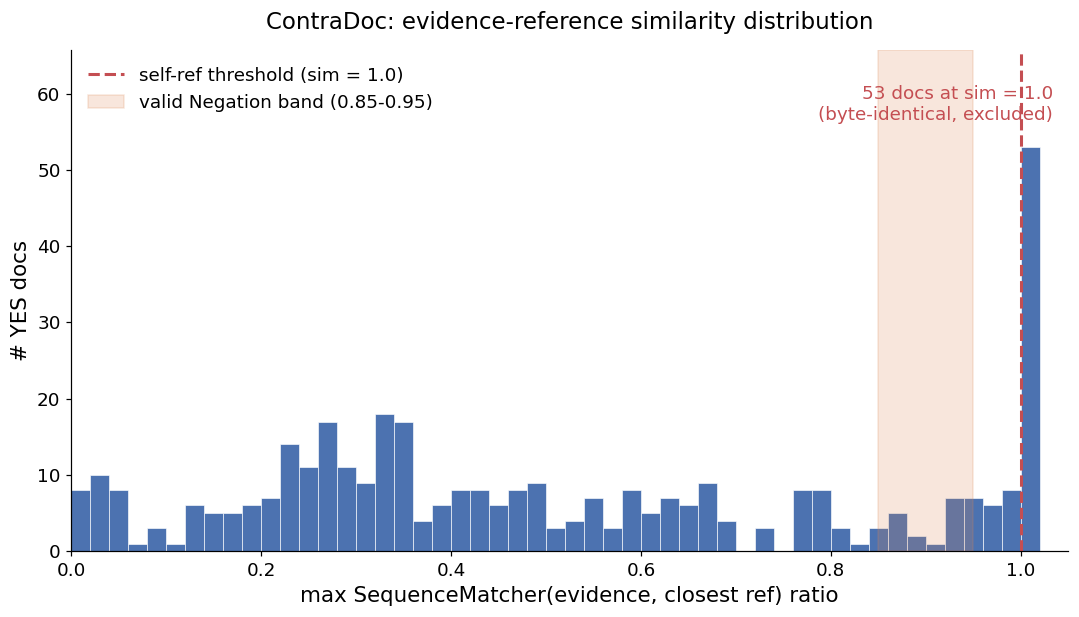

In [9]:
fig, ax = plt.subplots(figsize=(10, 5.8))
sims = res_df["self_ref_sim"].to_numpy()
bins = np.linspace(0.0, 1.02, 52)
ax.hist(sims, bins=bins, color="#4C72B0", edgecolor="white", linewidth=0.4)
ax.axvline(SELF_REF_THRESHOLD, color="#C44E52", linestyle="--", linewidth=2.0, label=f"self-ref threshold (sim = {SELF_REF_THRESHOLD})")
ax.axvspan(0.85, 0.95, color="#DD8452", alpha=0.20, label="valid Negation band (0.85-0.95)")
n_at_one = int((sims >= 1.0).sum())
ax.text(
    0.985, 0.93, f"{n_at_one} docs at sim = 1.0\n(byte-identical, excluded)",
    transform=ax.transAxes, ha="right", va="top", fontsize=12, color="#C44E52",
)
ax.set_xlabel("max SequenceMatcher(evidence, closest ref) ratio")
ax.set_ylabel("# YES docs")
ax.set_title("ContraDoc: evidence-reference similarity distribution", pad=14)
ax.set_xlim(0, 1.05)
ax.set_ylim(top=ax.get_ylim()[1] * 1.18)
ax.legend(loc="upper left", frameon=False)
fig.tight_layout()
fig.savefig(PLOT_DIR / "self_ref_similarity_dist.png")
plt.show()


### Plot 2 - YES doc usability by doc_type

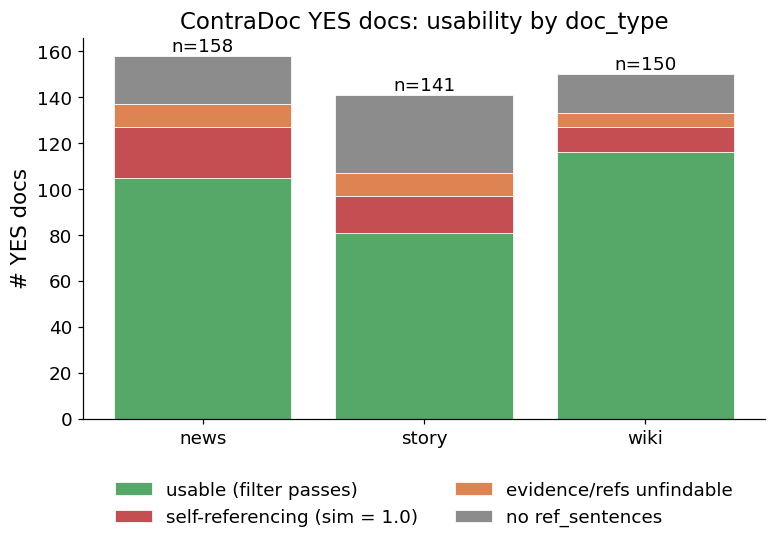

In [10]:
no_ref_by_type = yes[yes["ref_sentences"] == "none"].groupby("doc_type").size()
checked_by_type = res_df.groupby("doc_type").apply(
    lambda g: pd.Series(
        {
            "usable": int(g["usable"].sum()),
            "self_ref": int((g["self_ref"] & g["fully_findable"]).sum()),
            "not_findable": int((~g["fully_findable"]).sum()),
        }
    ),
    include_groups=False,
)
stacked = checked_by_type.copy()
stacked["no_ref"] = no_ref_by_type.reindex(stacked.index, fill_value=0).astype(int)
stacked = stacked[["usable", "self_ref", "not_findable", "no_ref"]]

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = {"usable": "#55A868", "self_ref": "#C44E52", "not_findable": "#DD8452", "no_ref": "#8C8C8C"}
labels = {
    "usable": "usable (filter passes)",
    "self_ref": "self-referencing (sim = 1.0)",
    "not_findable": "evidence/refs unfindable",
    "no_ref": "no ref_sentences",
}
bottom = np.zeros(len(stacked))
x = np.arange(len(stacked))
for col in stacked.columns:
    ax.bar(x, stacked[col].to_numpy(), bottom=bottom, color=colors[col], label=labels[col], edgecolor="white", linewidth=0.5)
    bottom = bottom + stacked[col].to_numpy()
for xi, total in zip(x, stacked.sum(axis=1)):
    ax.text(xi, total + 2, f"n={int(total)}", ha="center", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(stacked.index)
ax.set_ylabel("# YES docs")
ax.set_title("ContraDoc YES docs: usability by doc_type")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False)
fig.savefig(PLOT_DIR / "yes_doc_status_by_doctype.png")
plt.show()

### Plot 3 - Filter cascade

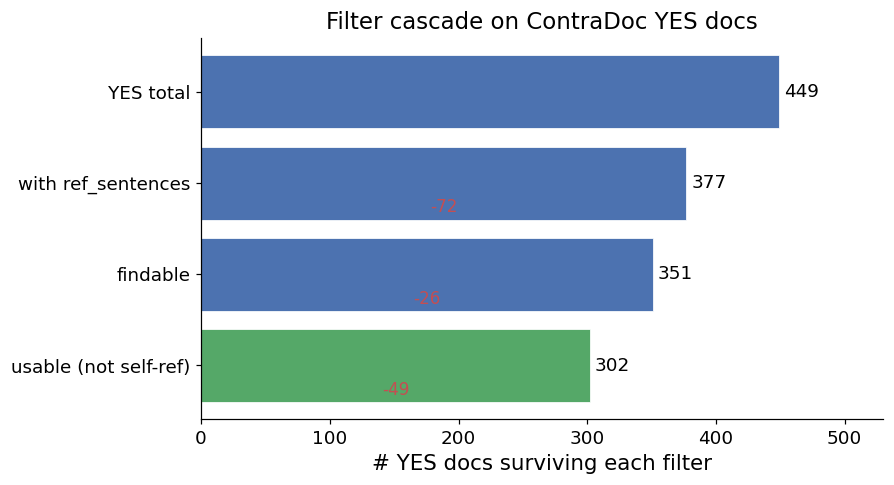

In [11]:
n_yes = int(len(yes))
n_with_ref = int(len(yes_with_ref))
n_findable = int(res_df["fully_findable"].sum())
n_usable = int(res_df["usable"].sum())
stages = [
    ("YES total", n_yes),
    ("with ref_sentences", n_with_ref),
    ("findable", n_findable),
    ("usable (not self-ref)", n_usable),
]
labels_, values_ = zip(*stages)
drops = [values_[i - 1] - v for i, v in enumerate(values_) if i > 0]

fig, ax = plt.subplots(figsize=(8, 4.5))
y = np.arange(len(stages))[::-1]
bar_colors = ["#4C72B0", "#4C72B0", "#4C72B0", "#55A868"]
ax.barh(y, values_, color=bar_colors, edgecolor="white", linewidth=0.5)
for yi, (lab, val) in zip(y, stages):
    ax.text(val + 4, yi, f"{val}", va="center", fontsize=12)
for i, drop in enumerate(drops, start=1):
    if drop <= 0:
        continue
    yi = y[i]
    ax.text(values_[i] / 2, yi - 0.32, f"-{drop}", ha="center", color="#C44E52", fontsize=11)
ax.set_yticks(y)
ax.set_yticklabels(labels_)
ax.set_xlabel("# YES docs surviving each filter")
ax.set_title("Filter cascade on ContraDoc YES docs")
ax.set_xlim(0, max(values_) * 1.18)
fig.savefig(PLOT_DIR / "filter_cascade.png")
plt.show()

## Sample composition

Five additional descriptive checks of the YES population (using the *usable* subset where the metric requires a clean gold pair, the full YES set otherwise).

### 4 - contra_type distribution and co-occurrence

ContraDoc's `contra_type` is pipe-separated multi-label. Tokenize each YES doc's contra_type, count token frequencies, and build a co-occurrence matrix to reveal which types travel together.

Multi-label distribution (usable YES docs, n=302):
  single-label docs: 147
  multi-label docs:  155
  max labels on one doc: 4

Per-token frequency:
  Content                           190
  Perspective/View/Opinion          64
  Negation                          63
  Numeric                           57
  Emotion/Mood/Feeling              56
  Factual                           33
  Relation                          18
  Causal                            9
  Other                             1


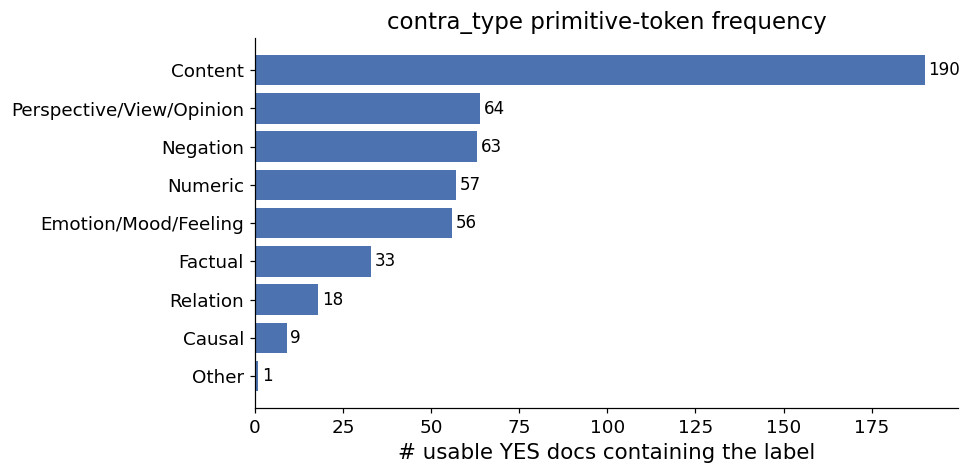

In [12]:
yes_usable_df = res_df[res_df["usable"]].copy()
tokens_per_doc = yes_usable_df["contra_type"].fillna("none").map(
    lambda s: [t.strip() for t in str(s).split("|") if t.strip()]
)
n_labels_per_doc = tokens_per_doc.map(len)
all_tokens = [t for toks in tokens_per_doc for t in toks]
freq = Counter(all_tokens)
type_order = [t for t, _ in freq.most_common()]

print(f"Multi-label distribution (usable YES docs, n={len(yes_usable_df)}):")
print(f"  single-label docs: {(n_labels_per_doc == 1).sum()}")
print(f"  multi-label docs:  {(n_labels_per_doc >= 2).sum()}")
print(f"  max labels on one doc: {int(n_labels_per_doc.max())}")
print()
print("Per-token frequency:")
for t, c in freq.most_common():
    print(f"  {t:<32s}  {c}")

# Plot 4a: contra_type token frequency
fig, ax = plt.subplots(figsize=(9, max(4.5, 0.35 * len(type_order))))
y = np.arange(len(type_order))[::-1]
ax.barh(y, [freq[t] for t in type_order], color="#4C72B0")
for yi, t in zip(y, type_order):
    ax.text(freq[t] + 1, yi, str(freq[t]), va="center", fontsize=11)
ax.set_yticks(y)
ax.set_yticklabels(type_order)
ax.set_xlabel("# usable YES docs containing the label")
ax.set_title("contra_type primitive-token frequency")
fig.tight_layout()
fig.savefig(PLOT_DIR / "contra_type_token_frequency.png")
plt.show()


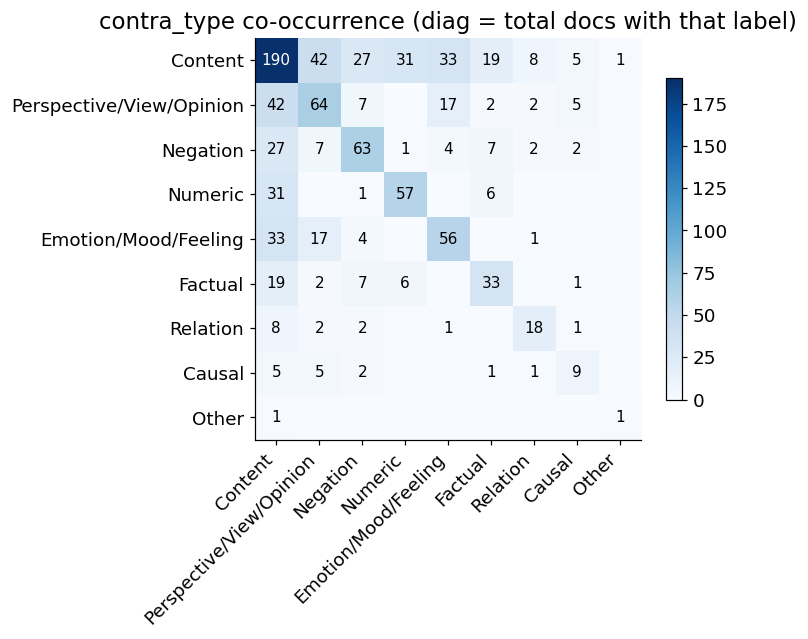

In [13]:
# Plot 4b: contra_type co-occurrence heatmap (diag = total docs with that label)
co = pd.DataFrame(0, index=type_order, columns=type_order, dtype=int)
for toks in tokens_per_doc:
    for a in toks:
        co.at[a, a] += 1
    for a, b in combinations(set(toks), 2):
        co.at[a, b] += 1
        co.at[b, a] += 1

fig, ax = plt.subplots(figsize=(max(7, 0.6 * len(type_order)), max(6, 0.55 * len(type_order))))
im = ax.imshow(co.to_numpy(), cmap="Blues", aspect="auto")
ax.set_xticks(range(len(type_order)))
ax.set_xticklabels(type_order, rotation=45, ha="right")
ax.set_yticks(range(len(type_order)))
ax.set_yticklabels(type_order)
for i in range(len(type_order)):
    for j in range(len(type_order)):
        v = int(co.iat[i, j])
        if v == 0:
            continue
        ax.text(j, i, str(v), ha="center", va="center",
                color="white" if v > co.values.max() / 2 else "black", fontsize=10)
ax.set_title("contra_type co-occurrence (diag = total docs with that label)")
fig.colorbar(im, ax=ax, shrink=0.8)
fig.tight_layout()
fig.savefig(PLOT_DIR / "contra_type_cooccurrence.png")
plt.show()


### 5 - Document length (sentences and tokens)

Practical: any doc near the gpt-5.4 context limit? Methodological: longer docs produce more candidate pairs and dilute retrieval precision -- worth stratifying RQ1/RQ2 results by length.

n_sentences     min=4  median=35  mean=37.5  p95=71  max=117
n_tokens        min=251  median=733  mean=805.5  p95=1487  max=1689

By doc_type (median tokens):
          min  median  mean   max
doc_type                         
news      251     716   756  1665
story     265     486   521   985
wiki      330    1166  1130  1689


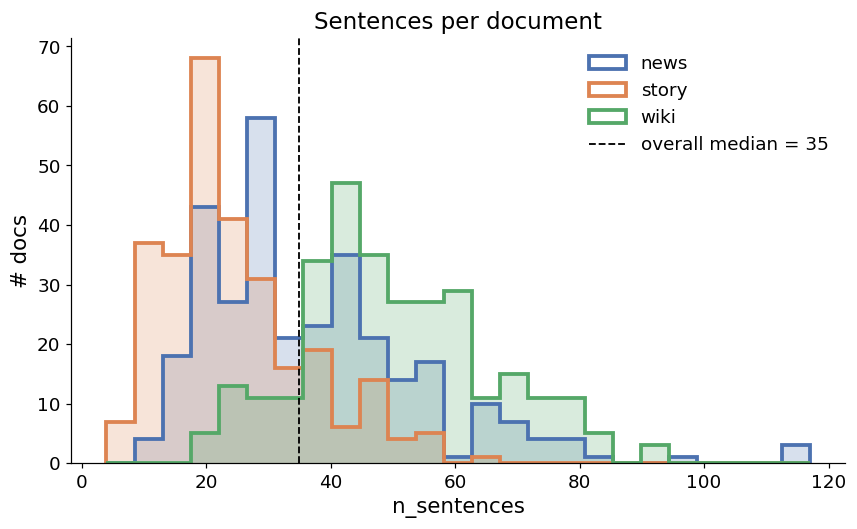

In [14]:
# Compute on all 891 docs (length is a property of text, not gold).
df["n_sentences"] = df["text"].map(lambda t: len(split_sentences(t)))
df["n_tokens"] = df["text"].map(lambda t: len(t.split()))

for col in ("n_sentences", "n_tokens"):
    s = df[col]
    print(f"{col:<14}  min={int(s.min())}  median={int(s.median())}  mean={s.mean():.1f}  p95={int(s.quantile(0.95))}  max={int(s.max())}")
print()
print("By doc_type (median tokens):")
print(df.groupby("doc_type")["n_tokens"].agg(["min", "median", "mean", "max"]).astype(int).to_string())

doctype_colors = {"news": "#4C72B0", "story": "#DD8452", "wiki": "#55A868"}

# Plot 5a: sentences per document
fig, ax = plt.subplots(figsize=(8, 5.0))
col = "n_sentences"
bin_edges = np.linspace(df[col].min(), df[col].max(), 26)
for dt, sub in df.groupby("doc_type"):
    ax.hist(sub[col], bins=bin_edges, histtype="stepfilled", color=doctype_colors[dt], alpha=0.22)
    ax.hist(sub[col], bins=bin_edges, histtype="step", linewidth=2.5, color=doctype_colors[dt], label=dt)
overall_median = int(df[col].median())
ax.axvline(overall_median, color="black", linestyle="--", linewidth=1.2, label=f"overall median = {overall_median}")
ax.set_xlabel(col)
ax.set_ylabel("# docs")
ax.set_title("Sentences per document")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(PLOT_DIR / "doc_length_sentences.png")
plt.show()


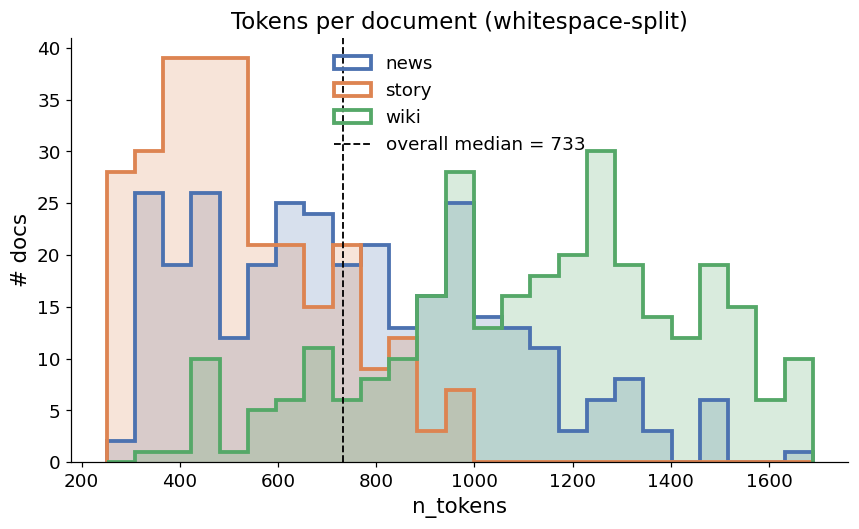

In [15]:
# Plot 5b: tokens per document (whitespace-split)
fig, ax = plt.subplots(figsize=(8, 5.0))
col = "n_tokens"
bin_edges = np.linspace(df[col].min(), df[col].max(), 26)
for dt, sub in df.groupby("doc_type"):
    ax.hist(sub[col], bins=bin_edges, histtype="stepfilled", color=doctype_colors[dt], alpha=0.22)
    ax.hist(sub[col], bins=bin_edges, histtype="step", linewidth=2.5, color=doctype_colors[dt], label=dt)
overall_median = int(df[col].median())
ax.axvline(overall_median, color="black", linestyle="--", linewidth=1.2, label=f"overall median = {overall_median}")
ax.set_xlabel(col)
ax.set_ylabel("# docs")
ax.set_title("Tokens per document (whitespace-split)")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(PLOT_DIR / "doc_length_tokens.png")
plt.show()


### 6 - Same-base-doc clusters

Numeric IDs like `3499318673_1` / `3499318673_3` share a base prefix - same source document with different inserted contradictions. **Critical for downstream NLI fine-tuning splits**: variants of one base story share text and must not split across train/test, otherwise the model leaks. The `news_train_*` / `story_train_*` IDs are unique base docs already.

YES docs:                  449
Unique base docs:          234
Bases with >=2 variants:   119
YES docs in multi-variant clusters: 334
Median variants per multi-variant base: 2
Max variants on one base:  7

Top 10 most-variant bases:
  base=3488771839     variants=7  e.g. ['3488771839_1', '3488771839_11', '3488771839_3', '3488771839_4']
  base=3499318678     variants=7  e.g. ['3499318678_1', '3499318678_2', '3499318678_3', '3499318678_5']
  base=3488771854     variants=6  e.g. ['3488771854_1', '3488771854_6', '3488771854_8', '3488771854_10']
  base=3499318689     variants=6  e.g. ['3499318689_10', '3499318689_1', '3499318689_3', '3499318689_4']
  base=3499318675     variants=6  e.g. ['3499318675_1', '3499318675_2', '3499318675_4', '3499318675_7']
  base=3488771840     variants=5  e.g. ['3488771840_2', '3488771840_5', '3488771840_7', '3488771840_9']
  base=3499318679     variants=5  e.g. ['3499318679_7', '3499318679_3', '3499318679_4', '3499318679_6']
  base=3489738255     variants=5  e.g

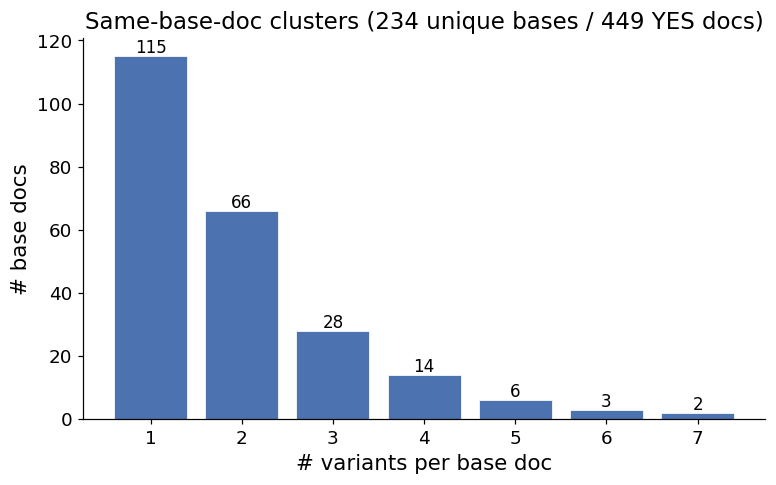

In [16]:
_NUM_VARIANT_RE = re.compile(r"^(\d+)_\d+$")


def base_doc_id(doc_id: str) -> str:
    """Strip _N suffix only when the doc_id is fully numeric (e.g. 3499318673_1 -> 3499318673).
    Leaves story_train_8472 / news_train_55 etc. unchanged."""
    m = _NUM_VARIANT_RE.match(str(doc_id))
    return m.group(1) if m else str(doc_id)


yes_base = yes["id"].astype(str).map(base_doc_id)
variants_per_base = yes_base.value_counts()
n_unique_bases = variants_per_base.size
n_yes_docs = len(yes)
n_multivariant_bases = (variants_per_base > 1).sum()
n_docs_in_multi = int(variants_per_base[variants_per_base > 1].sum())

print(f"YES docs:                  {n_yes_docs}")
print(f"Unique base docs:          {n_unique_bases}")
print(f"Bases with >=2 variants:   {n_multivariant_bases}")
print(f"YES docs in multi-variant clusters: {n_docs_in_multi}")
print(f"Median variants per multi-variant base: {int(variants_per_base[variants_per_base > 1].median()) if n_multivariant_bases else 0}")
print(f"Max variants on one base:  {int(variants_per_base.max())}")
print()
print("Top 10 most-variant bases:")
for base, k in variants_per_base.head(10).items():
    sample_ids = yes.loc[yes_base == base, "id"].head(4).tolist()
    print(f"  base={base:<14} variants={k}  e.g. {sample_ids}")

fig, ax = plt.subplots(figsize=(8, 4.5))
vc = variants_per_base.value_counts().sort_index()
ax.bar(vc.index, vc.values, color="#4C72B0", edgecolor="white", linewidth=0.5)
for xi, yi in zip(vc.index, vc.values):
    ax.text(xi, yi + 1, str(int(yi)), ha="center", fontsize=11)
ax.set_xlabel("# variants per base doc")
ax.set_ylabel("# base docs")
ax.set_title(f"Same-base-doc clusters ({n_unique_bases} unique bases / {n_yes_docs} YES docs)")
ax.set_xticks(vc.index)
fig.savefig(PLOT_DIR / "base_doc_clusters.png")
plt.show()

### 7 - Number of refs per YES doc

n_refs distribution (across 377 YES docs with refs):
  1 ref     321  (85.1%)
  2 refs     56  (14.9%)
  median n_refs: 1, max: 2


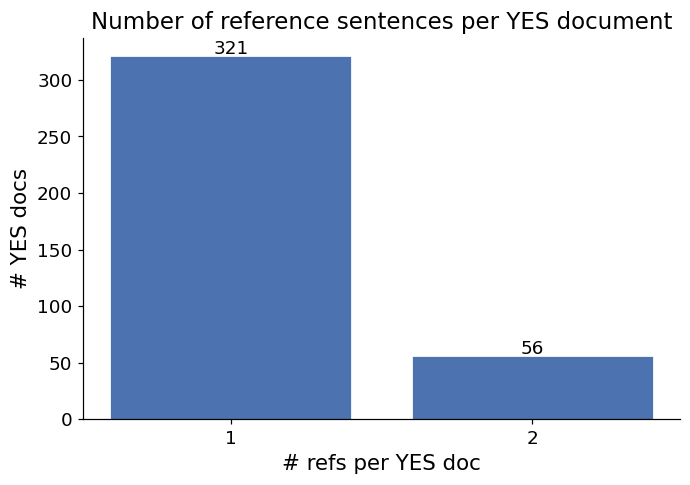

In [17]:
n_refs_dist = res_df["n_refs"].value_counts().sort_index()
print(f"n_refs distribution (across {len(res_df)} YES docs with refs):")
for k, v in n_refs_dist.items():
    print(f"  {k} ref{'s' if k != 1 else '':<2}  {v:>4}  ({v / len(res_df):.1%})")
print(f"  median n_refs: {int(res_df['n_refs'].median())}, max: {int(res_df['n_refs'].max())}")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(n_refs_dist.index, n_refs_dist.values, color="#4C72B0", edgecolor="white", linewidth=0.5)
for xi, yi in zip(n_refs_dist.index, n_refs_dist.values):
    ax.text(xi, yi + 2, str(int(yi)), ha="center", fontsize=12)
ax.set_xlabel("# refs per YES doc")
ax.set_ylabel("# YES docs")
ax.set_title("Number of reference sentences per YES document")
ax.set_xticks(n_refs_dist.index)
fig.savefig(PLOT_DIR / "n_refs_per_doc.png")
plt.show()

### 8 - Evidence/reference position and inter-distance

Sentence indices for each YES doc's gold evidence and gold ref(s), normalized to [0, 1] by document length. Shows whether contradictions cluster near document edges and how far apart the evidence and ref sentences sit. The latter is a confound for RQ1 (structural retrieval, local) vs RQ2 (vector retrieval, global).

Position pairs (usable, ev+ref both indexed): 330
  median distance (sentences):    3
  median distance (normalized):   0.130
  evidence position quartiles: [0.2, 0.452, 0.739]
  ref      position quartiles: [0.133, 0.415, 0.741]


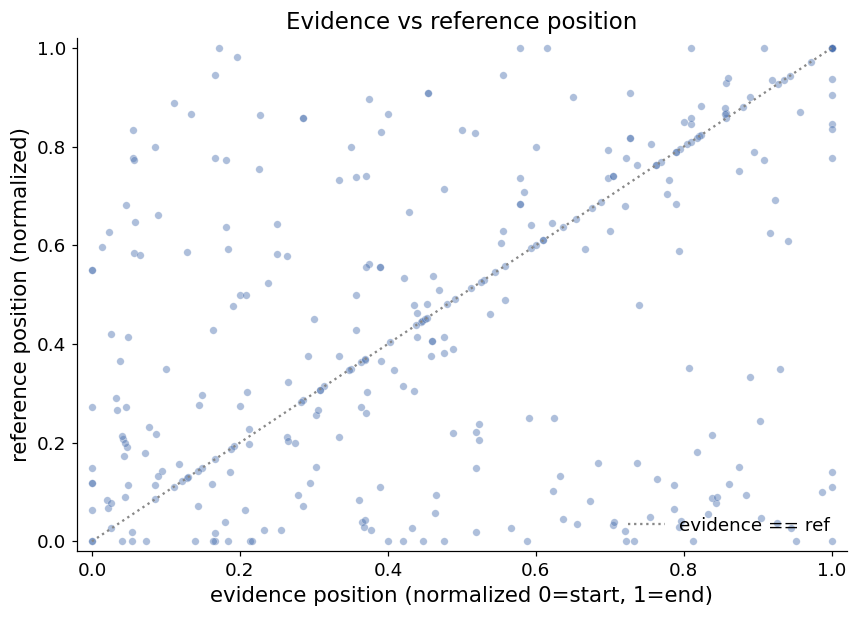

In [18]:
pos_records: list[dict] = []
for r in res_df[res_df["usable"]].itertuples(index=False):
    if r.evidence_idx < 0 or r.n_sentences <= 0:
        continue
    ev_pos = r.evidence_idx / max(r.n_sentences - 1, 1)
    for ref_idx in r.refs_idxs:
        if ref_idx < 0:
            continue
        ref_pos = ref_idx / max(r.n_sentences - 1, 1)
        pos_records.append(
            {
                "doc_id": r.doc_id,
                "doc_type": r.doc_type,
                "evidence_pos": ev_pos,
                "ref_pos": ref_pos,
                "distance_normalized": abs(ev_pos - ref_pos),
                "distance_sentences": abs(r.evidence_idx - ref_idx),
            }
        )
pos_df = pd.DataFrame(pos_records)
print(f"Position pairs (usable, ev+ref both indexed): {len(pos_df)}")
print(f"  median distance (sentences):    {pos_df['distance_sentences'].median():.0f}")
print(f"  median distance (normalized):   {pos_df['distance_normalized'].median():.3f}")
print(f"  evidence position quartiles: {pos_df['evidence_pos'].quantile([0.25, 0.5, 0.75]).round(3).to_list()}")
print(f"  ref      position quartiles: {pos_df['ref_pos'].quantile([0.25, 0.5, 0.75]).round(3).to_list()}")

# Plot 8a: evidence vs reference position scatter
fig, ax = plt.subplots(figsize=(8, 5.8))
ax.scatter(pos_df["evidence_pos"], pos_df["ref_pos"], s=24, alpha=0.45, color="#4C72B0", edgecolor="white", linewidth=0.3)
ax.plot([0, 1], [0, 1], color="#888", linestyle=":", linewidth=1.5, label="evidence == ref")
ax.set_xlabel("evidence position (normalized 0=start, 1=end)")
ax.set_ylabel("reference position (normalized)")
ax.set_title("Evidence vs reference position")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.legend(frameon=False, loc="lower right")
fig.tight_layout()
fig.savefig(PLOT_DIR / "evidence_ref_position_scatter.png")
plt.show()


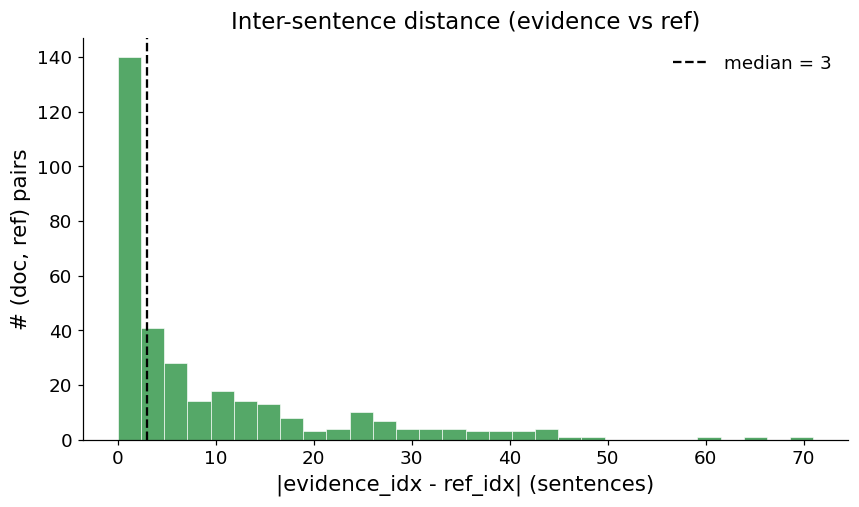

In [19]:
# Plot 8b: inter-sentence distance histogram
median_dist = int(pos_df["distance_sentences"].median())
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.hist(pos_df["distance_sentences"], bins=30, color="#55A868", edgecolor="white", linewidth=0.4)
ax.axvline(median_dist, color="black", linestyle="--", linewidth=1.5, label=f"median = {median_dist}")
ax.set_xlabel("|evidence_idx - ref_idx| (sentences)")
ax.set_ylabel("# (doc, ref) pairs")
ax.set_title("Inter-sentence distance (evidence vs ref)")
ax.legend(frameon=False, loc="upper right")
fig.tight_layout()
fig.savefig(PLOT_DIR / "evidence_ref_distance_histogram.png")
plt.show()


## Persist usable / excluded lists + base-doc clusters

`findability.json` carries the filter lists AND the base-doc grouping for downstream group-aware splits (notably for the planned NLI fine-tuning task).

In [20]:
usable_ids = sorted(res_df.loc[res_df["usable"], "doc_id"].astype(str).tolist())
not_findable_ids = sorted(res_df.loc[~res_df["fully_findable"], "doc_id"].astype(str).tolist())
self_ref_ids = sorted(res_df.loc[res_df["self_ref"], "doc_id"].astype(str).tolist())
no_ref_yes_ids = sorted(yes.loc[yes["ref_sentences"] == "none", "id"].astype(str).tolist())

# Group every YES doc_id under its base prefix (for NLI splits / leakage prevention).
base_to_variants: dict[str, list[str]] = defaultdict(list)
for did in yes["id"].astype(str):
    base_to_variants[base_doc_id(did)].append(did)
base_to_variants = {b: sorted(v) for b, v in sorted(base_to_variants.items())}

payload = {
    "criteria": {
        "fully_findable": (
            "YES doc's `evidence` and ALL pipe-separated `ref_sentences` are locatable in `text` "
            f"either as exact normalized substring or via sentence-level SequenceMatcher >= {FUZZY_THRESHOLD}."
        ),
        "not_self_referencing": (
            f"Max SequenceMatcher(evidence, ref) < {SELF_REF_THRESHOLD}; evidence is NOT byte-identical to any ref "
            "after normalization. Strict 1.0 cut keeps single-word negation/antonym/number contradictions."
        ),
        "usable": "fully_findable AND not_self_referencing",
        "base_doc_id": (
            "For numeric doc_ids of the form '<base>_<variant>' (e.g. 3499318673_1), base = '<base>'. "
            "For 'story_train_*', 'news_train_*', and similar, base = full doc_id. Use base for NLI train/test "
            "splits to prevent text leakage between variants of the same source document."
        ),
    },
    "thresholds": {
        "fuzzy_match": FUZZY_THRESHOLD,
        "self_reference": SELF_REF_THRESHOLD,
    },
    "counts": {
        "yes_total": int(len(yes)),
        "yes_with_ref": int(len(yes_with_ref)),
        "yes_no_ref": len(no_ref_yes_ids),
        "not_findable": len(not_findable_ids),
        "self_referencing": len(self_ref_ids),
        "usable": len(usable_ids),
        "yes_unique_base_docs": len(base_to_variants),
    },
    "usable_doc_ids": usable_ids,
    "not_findable_doc_ids": not_findable_ids,
    "self_referencing_doc_ids": self_ref_ids,
    "yes_no_ref_doc_ids": no_ref_yes_ids,
    "yes_base_doc_groups": base_to_variants,
}

OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH.write_text(json.dumps(payload, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"Saved {OUTPUT_PATH.resolve()}")
print(f"  usable:              {len(usable_ids)}")
print(f"  not_findable:        {len(not_findable_ids)}")
print(f"  self_referencing:    {len(self_ref_ids)}")
print(f"  yes_no_ref:          {len(no_ref_yes_ids)}")
print(f"  yes_unique_bases:    {len(base_to_variants)}")

Saved D:\AT82.05-Claim-Contradiction-Over-Knowledge-Graphs\experiments\data\processed\ContraDoc\findability.json
  usable:              302
  not_findable:        26
  self_referencing:    53
  yes_no_ref:          72
  yes_unique_bases:    234


## Balanced contra-type sample for downstream extraction

The naive choice would be to sample uniformly from the 302 usable YES docs, but `contra_type` is multi-label (e.g. `Content|Numeric|Negation`) with skewed primitives, and `doc_type` (wiki / news / story) is also imbalanced. Uniform sampling under-trains the rare primitives and over-weights the largest doc_type.

The sampler below is **two-level**:
1. Allocate equal quotas across `doc_type` (~67 + ~67 + ~66 for `n=200`); the remainder goes to the largest doc_types first.
2. Within each doc_type bucket, run a greedy primitive-`contra_type` balancer: each step picks the primitive label with the lowest cumulative coverage, then a random unpicked doc that contains it. A doc tagged `Content|Numeric` increments BOTH counters, so co-occurring labels are credited correctly.

**Output:** `data/processed/ContraDoc/balanced_sample.json` with `doc_ids` plus full vs sample counts on both axes, for downstream notebooks (02b extraction, 06 NLI splits) to load.


Excluded 1 docs whose contra_type contains ['Other']
  remaining usable YES pool: 301

doc_type quotas (n_target=150, k=3):
  wiki        target=50  available=116
  news        target=50  available=104
  story       target=50  available=81

Sampled 150 of 301 usable YES docs (target 150).

primitive                          full   sample   sample %
------------------------------------------------------------
Content                             189       91      48.1%
Perspective/View/Opinion             64       41      64.1%
Negation                             63       38      60.3%
Numeric                              57       27      47.4%
Emotion/Mood/Feeling                 56       39      69.6%
Factual                              33       27      81.8%
Relation                             18       18     100.0%
Causal                                9        9     100.0%

doc_type     full   sample
------------------------------
news          104       50
story          81     

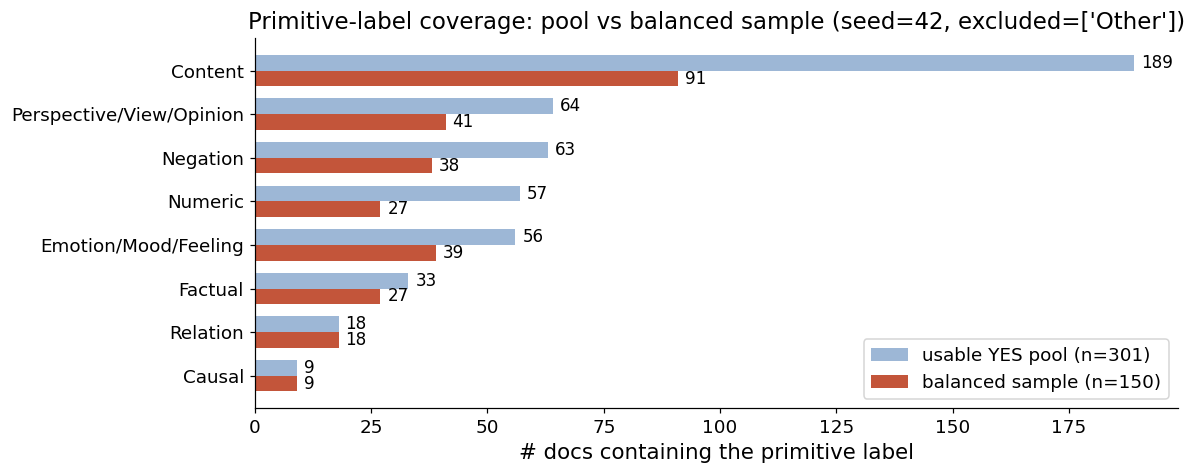

Saved D:\AT82.05-Claim-Contradiction-Over-Knowledge-Graphs\experiments\data\processed\ContraDoc\balanced_sample.json
  doc_ids: 150


In [21]:
BALANCED_SAMPLE_N = 150
BALANCED_SEED = 42
# Primitives we drop from the sampling pool because their support is too low
# to stratify or train on. ContraDoc has exactly 1 doc tagged "Other".
EXCLUDED_PRIMITIVES = frozenset({"Other"})
BALANCED_PATH = Path("data/processed/ContraDoc/balanced_sample.json")


def _split_primitives(s: str, sep: str = "|") -> frozenset[str]:
    return frozenset(t.strip() for t in str(s).split(sep) if t.strip())


def balanced_sample_multilabel(df: pd.DataFrame, label_col: str, n_target: int, seed: int) -> pd.DataFrame:
    """Greedy round-robin: each step pick the primitive label with the lowest
    cumulative count, then a random unpicked doc that has that label.
    Iterates until n_target docs are picked or the pool is exhausted."""
    rng = np.random.default_rng(seed)
    df_r = df.reset_index(drop=True)
    doc_labels = df_r[label_col].fillna("").map(_split_primitives)

    label_to_idxs: dict[str, list[int]] = {}
    for i, labs in enumerate(doc_labels):
        for lab in labs:
            label_to_idxs.setdefault(lab, []).append(i)

    label_count: Counter = Counter({lab: 0 for lab in label_to_idxs})
    picked: set[int] = set()

    while len(picked) < n_target:
        for lab, _ in sorted(label_count.items(), key=lambda kv: (kv[1], kv[0])):
            candidates = [i for i in label_to_idxs[lab] if i not in picked]
            if not candidates:
                continue
            chosen = int(rng.choice(candidates))
            picked.add(chosen)
            for l in doc_labels[chosen]:
                label_count[l] += 1
            break
        else:
            break

    return df_r.iloc[sorted(picked)].reset_index(drop=True)


def balanced_sample_multilabel_by_doctype(
    df: pd.DataFrame,
    label_col: str,
    doctype_col: str,
    n_target: int,
    seed: int,
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    doctype_counts = df[doctype_col].value_counts()
    doctypes = list(doctype_counts.index)
    k = len(doctypes)
    base = n_target // k
    extra = n_target - base * k
    targets = {dt: base + (1 if i < extra else 0) for i, dt in enumerate(doctypes)}

    print(f"doc_type quotas (n_target={n_target}, k={k}):")
    for dt, t in targets.items():
        avail = int(doctype_counts[dt])
        flag = "  (capped to availability)" if avail < t else ""
        print(f"  {dt:<10s}  target={t}  available={avail}{flag}")
    print()

    chunks = []
    for dt, target in targets.items():
        sub = df[df[doctype_col] == dt]
        if len(sub) < target:
            chunks.append(sub.copy())
        else:
            chunks.append(
                balanced_sample_multilabel(
                    sub, label_col, target, seed=int(rng.integers(0, 10**9))
                )
            )
    return pd.concat(chunks).reset_index(drop=True)


# --- Drop docs containing excluded primitives (singletons) -------------------
def _has_excluded(s: str) -> bool:
    return bool(_split_primitives(s) & EXCLUDED_PRIMITIVES)


excluded_mask = yes_usable_df["contra_type"].fillna("").map(_has_excluded)
n_excluded = int(excluded_mask.sum())
yes_usable_df = yes_usable_df[~excluded_mask].reset_index(drop=True)
print(f"Excluded {n_excluded} docs whose contra_type contains {sorted(EXCLUDED_PRIMITIVES)}")
print(f"  remaining usable YES pool: {len(yes_usable_df)}")
print()


# --- Run the sampler ---------------------------------------------------------
balanced_df = balanced_sample_multilabel_by_doctype(
    yes_usable_df,
    label_col="contra_type",
    doctype_col="doc_type",
    n_target=BALANCED_SAMPLE_N,
    seed=BALANCED_SEED,
)
print(f"Sampled {len(balanced_df)} of {len(yes_usable_df)} usable YES docs (target {BALANCED_SAMPLE_N}).")
print()


# --- Compare primitive-label coverage before vs after ------------------------
def _primitive_counts(df: pd.DataFrame) -> Counter:
    c: Counter = Counter()
    for s in df["contra_type"].fillna(""):
        c.update(_split_primitives(s))
    return c


full_counts = _primitive_counts(yes_usable_df)
sample_counts = _primitive_counts(balanced_df)
all_labels = sorted(full_counts.keys(), key=lambda l: (-full_counts[l], l))

print(f"{'primitive':<32s} {'full':>6s} {'sample':>8s} {'sample %':>10s}")
print("-" * 60)
for lab in all_labels:
    full_n = full_counts[lab]
    samp_n = sample_counts.get(lab, 0)
    pct = (samp_n / full_n * 100) if full_n else 0.0
    print(f"{lab:<32s} {full_n:>6d} {samp_n:>8d} {pct:>9.1f}%")
print()

full_dt = yes_usable_df["doc_type"].value_counts().to_dict()
samp_dt = balanced_df["doc_type"].value_counts().to_dict()
all_dt = sorted(set(full_dt) | set(samp_dt))
print(f"{'doc_type':<10s} {'full':>6s} {'sample':>8s}")
print("-" * 30)
for dt in all_dt:
    print(f"{dt:<10s} {full_dt.get(dt, 0):>6d} {samp_dt.get(dt, 0):>8d}")
print()


# --- Plot: primitive-label coverage (single chart) ---------------------------
fig, ax = plt.subplots(figsize=(11, max(4.5, 0.42 * len(all_labels))))
y = np.arange(len(all_labels))[::-1]
full_vals = [full_counts[lab] for lab in all_labels]
samp_vals = [sample_counts.get(lab, 0) for lab in all_labels]
ax.barh(y + 0.18, full_vals, height=0.36, color="#9DB7D6", label=f"usable YES pool (n={len(yes_usable_df)})")
ax.barh(y - 0.18, samp_vals, height=0.36, color="#C3553A", label=f"balanced sample (n={len(balanced_df)})")
for yi, lab in zip(y, all_labels):
    ax.text(full_counts[lab] + 1.5, yi + 0.18, str(full_counts[lab]), va="center", fontsize=11)
    ax.text(sample_counts.get(lab, 0) + 1.5, yi - 0.18, str(sample_counts.get(lab, 0)), va="center", fontsize=11)
ax.set_yticks(y)
ax.set_yticklabels(all_labels)
ax.set_xlabel("# docs containing the primitive label")
ax.set_title(f"Primitive-label coverage: pool vs balanced sample (seed={BALANCED_SEED}, excluded={sorted(EXCLUDED_PRIMITIVES)})")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(PLOT_DIR / "balanced_sample_primitive_coverage.png")
plt.show()


# --- Persist the sample doc_ids ---------------------------------------------
balanced_payload = {
    "n_target": BALANCED_SAMPLE_N,
    "n_actual": int(len(balanced_df)),
    "seed": BALANCED_SEED,
    "label_col": "contra_type",
    "doctype_col": "doc_type",
    "excluded_primitives": sorted(EXCLUDED_PRIMITIVES),
    "n_excluded_from_pool": n_excluded,
    "criteria": (
        "Two-level stratified sample from the usable YES pool, with docs containing "
        "any primitive in EXCLUDED_PRIMITIVES dropped first (those primitives have "
        "support too low to stratify on). (1) Equal doc_type quotas with remainder "
        "to the largest doc_types first. (2) Within each doc_type, greedy primitive-"
        "contra_type balancing - each step picks the lowest-coverage primitive then "
        "a random unpicked doc containing it. A doc tagged 'Content|Numeric' counts "
        "toward both primitives."
    ),
    "doc_ids": sorted(balanced_df["doc_id"].astype(str).tolist()),
    "doctype_counts_full": {dt: int(full_dt.get(dt, 0)) for dt in all_dt},
    "doctype_counts_sample": {dt: int(samp_dt.get(dt, 0)) for dt in all_dt},
    "primitive_label_counts_full": dict(full_counts),
    "primitive_label_counts_sample": {lab: int(sample_counts.get(lab, 0)) for lab in all_labels},
}

BALANCED_PATH.parent.mkdir(parents=True, exist_ok=True)
BALANCED_PATH.write_text(json.dumps(balanced_payload, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"Saved {BALANCED_PATH.resolve()}")
print(f"  doc_ids: {len(balanced_payload['doc_ids'])}")


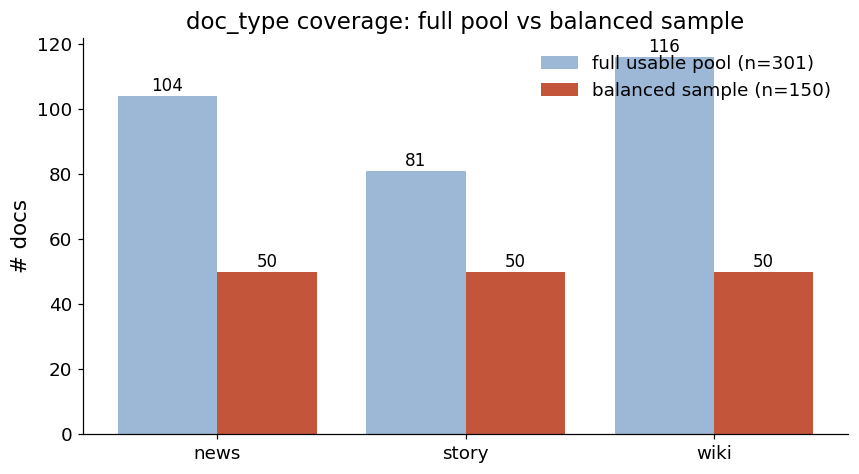

In [22]:
# doc_type coverage as its own chart
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(all_dt))
full_n = [full_dt.get(dt, 0) for dt in all_dt]
samp_n = [samp_dt.get(dt, 0) for dt in all_dt]
ax.bar(x - 0.2, full_n, width=0.4, color="#9DB7D6", label=f"full usable pool (n={len(yes_usable_df)})")
ax.bar(x + 0.2, samp_n, width=0.4, color="#C3553A", label=f"balanced sample (n={len(balanced_df)})")
for xi, fn, sn in zip(x, full_n, samp_n):
    ax.text(xi - 0.2, fn + 1.5, str(fn), ha="center", fontsize=11)
    ax.text(xi + 0.2, sn + 1.5, str(sn), ha="center", fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(all_dt)
ax.set_ylabel("# docs")
ax.set_title("doc_type coverage: full pool vs balanced sample")
ax.legend(frameon=False, loc="upper right")
fig.tight_layout()
fig.savefig(PLOT_DIR / "balanced_sample_doctype_coverage.png")
plt.show()


## Takeaway and how to apply downstream

**Filters for notebook 02 / 02b (and any subsequent extraction):**
1. **Findability** - drops docs whose evidence or any ref cannot be aligned to the document text.
2. **Self-reference (strict, sim == 1.0)** - drops docs whose evidence is byte-identical to a ref. Below 1.0 the differences are typically a single negation/antonym/number swap, which ARE the contradictions and stay in the usable set.
3. **Two-level balanced sample (200 of 302)** - on top of (1) and (2), the sampler enforces equal `doc_type` quotas (~67 wiki + ~67 news + ~66 story) AND, within each doc_type, greedy primitive-`contra_type` balancing so the rare phenomena (Negation, Causal, ...) are not under-represented. Use this as the canonical YES set for budget-bounded extraction runs and NLI training.

**Sample-composition findings to feed into report / handoffs:**
- `contra_type` distribution surfaces which contradiction types are over/under-represented for stratified sampling.
- Document-length distribution flags any context-window concerns and gives a covariate for retrieval analysis.
- Same-base-doc clusters identify variants of one source doc; required reading for the friend handling the binary NLI fine-tune (`yes_base_doc_groups` in `findability.json` is the group key for `GroupKFold` / `GroupShuffleSplit`).
- `n_refs` distribution shows the gold-pair multiplicity baseline.
- Evidence/ref position distribution highlights the inter-sentence distance covariate that may confound RQ1 vs RQ2.

**Apply the balanced sample in notebook 02b (preferred):**

```python
import json
from pathlib import Path

BALANCED_PATH = Path("data/processed/ContraDoc/balanced_sample.json")
balanced_ids = set(json.loads(BALANCED_PATH.read_text())["doc_ids"])

yes_balanced = contra_df[
    (contra_df["contradiction"] == "YES")
    & contra_df["id"].astype(str).isin(balanced_ids)
]
```

**Or apply only the usable filter (full 302 YES pool):**

```python
FINDABILITY_PATH = Path("data/processed/ContraDoc/findability.json")
usable_ids = set(json.loads(FINDABILITY_PATH.read_text())["usable_doc_ids"])

yes_usable = contra_df[
    (contra_df["contradiction"] == "YES")
    & (contra_df["ref_sentences"] != "none")
    & contra_df["id"].astype(str).isin(usable_ids)
]
```

**Apply group-aware split for NLI fine-tuning:**

```python
groups = json.loads(FINDABILITY_PATH.read_text())["yes_base_doc_groups"]
doc_to_base = {did: base for base, dids in groups.items() for did in dids}
# Use sklearn.model_selection.GroupKFold(n_splits=5).split(X, y, groups=[doc_to_base[d] for d in doc_ids])
```
